# Module 3: Decision-Theoretic Policy Optimization via Utility Maximization

Standard policy decisions tend to rely on point estimates, which implicitly assume that over-provisioning and under-provisioning are equally costly. In human rights service delivery, that assumption does not hold. Failing to serve a victim who needed help carries a fundamentally different human cost than funding a service slot that goes unused.

This module addresses that asymmetry using a **Bayesian Decision-Theoretic Model** built around the **Linear-Exponential (LINEX) loss function**:

$$L(S_c,\, y_c^*) = b_c \left[ \exp\!\left( a_c\,(y_c^* - S_c) \right) - a_c\,(y_c^* - S_c) - 1 \right]$$

When demand exceeds capacity, the loss grows exponentially. When capacity exceeds demand, it grows only linearly. The parameter $a_c$ controls how sharply the model penalizes under-provisioning for each service category.

**Sequential Least Squares Programming (SLSQP)** is used to find the capacity vector $\mathbf{S}$ that minimizes total expected loss across all MCMC demand scenarios subject to a budget constraint:

$$\min_{\mathbf{S}} \sum_c \mathbb{E}_{y_c^*}\left[ L(S_c, y_c^*) \right] \quad \text{subject to} \quad \sum_c \text{cost}_c \cdot S_c \leq B$$

**Data:** `02_ovc_victims_served_fy23_fy24.csv` (service capacity baseline and demand scenarios)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import arviz as az
from scipy.optimize import minimize

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', font_scale=1.05)
BASE = './'
rng  = np.random.default_rng(42)

## 1. Data Preparation: Service Capacity Baseline

In [2]:
df_ovc = pd.read_csv(BASE + '02_ovc_victims_served_fy23_fy24.csv')
print(df_ovc.shape)
df_ovc

(8, 8)


,fiscal_year,quarter,sex_trafficking,labor_trafficking,eligible_family_members,undetermined,sex_and_labor,quarterly_total
0,2024,Q1,2429,614,564,368,296,4271
1,2024,Q2,2385,659,492,268,261,4065
2,2024,Q3,2262,571,486,224,223,3766
3,2024,Q4,1990,559,468,325,197,3539
4,2023,Q1,1823,532,500,109,182,3146
5,2023,Q2,1971,610,558,208,84,3431
6,2023,Q3,2000,463,414,128,190,3195
7,2023,Q4,1892,451,425,201,178,3147


In [3]:
# Service categories
service_cats = ['sex_trafficking', 'labor_trafficking', 'eligible_family_members',
                'undetermined', 'sex_and_labor']

# NOTE: S_current is observed service delivery (FY2024 annual total), used as a
# capacity proxy. This reflects served demand, not true maximum capacity.
fy24 = df_ovc[df_ovc['fiscal_year'] == 2024]
fy23 = df_ovc[df_ovc['fiscal_year'] == 2023]

S_current = fy24[service_cats].sum().values.astype(float)
S_fy23    = fy23[service_cats].sum().values.astype(float)

print('Observed service delivery FY2024 (capacity proxy):')
for c, v in zip(service_cats, S_current):
    print(f'  {c}: {v:.0f}')

Observed service delivery FY2024 (capacity proxy):
  sex_trafficking: 9066
  labor_trafficking: 2403
  eligible_family_members: 2010
  undetermined: 1185
  sex_and_labor: 977


## 2. Module Integration: Connecting DLM and Beta-Binomial Outputs

The demand scenario matrix is built in two steps, each drawing directly from the upstream modules.

**Step A (Module 1):** The DLM is run inline on the Polaris hotline signal to extract the posterior residual `epsilon_t`. This residual captures how much recent observed demand deviates from the long-term structural trend. The average residual over the last two years is converted into a multiplicative adjustment factor that scales the OVC-based demand scenarios up or down accordingly.

**Step B (Module 2):** The Beta-Binomial posterior means of key coercion mechanisms from the CTDC dataset are used to calibrate the LINEX asymmetry parameter `a_c` for each service category. Categories where victims are more frequently subjected to severe control mechanisms receive a higher `a_c`, which makes the optimizer more conservative about leaving them under-resourced.

In [ ]:
#  Step A: Module 1 (DLM) extract residual demand signal 
df_polaris = pd.read_csv(BASE + '01_polaris_hotline_signals_fy2013_2024.csv')
y_raw  = df_polaris['potential_situations_identified'].values.astype(float)
years  = df_polaris['fiscal_year'].values
T      = len(y_raw)
y_mean, y_std = y_raw.mean(), y_raw.std()
y_std_arr     = (y_raw - y_mean) / y_std
X_fosta       = (years >= 2018).astype(float)

with pm.Model() as dlm_inline:
    sigma_mu   = pm.HalfNormal('sigma_mu',  sigma=1.0)
    sigma_eps  = pm.HalfNormal('sigma_eps', sigma=1.0)
    beta_fosta = pm.Normal('beta_fosta', mu=0, sigma=2)
    mu_init    = pm.Normal('mu_init',    mu=0, sigma=2)
    mu_innov   = pm.Normal('mu_innov',   mu=0, sigma=sigma_mu, shape=T - 1)
    mu_t       = pm.Deterministic(
        'mu_t',
        pm.math.concatenate([[mu_init], mu_init + pm.math.cumsum(mu_innov)])
    )
    pm.Normal('y_obs', mu=mu_t + beta_fosta * X_fosta, sigma=sigma_eps, observed=y_std_arr)

    dlm_trace = pm.sample(500, tune=500, chains=4, target_accept=0.95,
                          progressbar=False, random_seed=42)

# Posterior residual in original scale
mu_t_post    = dlm_trace.posterior['mu_t'].values.reshape(-1, T)
beta_post    = dlm_trace.posterior['beta_fosta'].values.flatten()
residual_std = y_std_arr[np.newaxis, :] - mu_t_post - np.outer(beta_post, X_fosta)
residual_orig = residual_std * y_std  # back to original scale

# Demand adjustment factor: how much recent demand exceeds the trend
residual_recent = residual_orig[:, -2:].mean()
trend_recent    = mu_t_post[:, -2:].mean() * y_std + y_mean
dlm_adj_factor  = float(1.0 + np.clip(residual_recent / trend_recent, -0.15, 0.30))

print(f'DLM posterior residual (last 2 yrs mean): {residual_recent:.1f}')
print(f'Demand adjustment factor from Module 1:   {dlm_adj_factor:.4f}')

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_mu, sigma_eps, beta_fosta, mu_init, mu_innov]
Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 3 seconds.
There were 49 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


DLM posterior residual (last 2 yrs mean): 5.0
Demand adjustment factor from Module 1:   1.0006


In [ ]:
#  Step A continued: OVC demand scenarios adjusted by DLM factor 
obs_matrix  = df_ovc[service_cats].values.astype(float)  # (8 quarters, 5 cats)
n_scenarios = 4000
n_cats      = len(service_cats)

demand_scenarios = np.zeros((n_scenarios, n_cats))

for i, cat in enumerate(service_cats):
    q_obs = obs_matrix[:, i]

    with pm.Model() as demand_model:
        mu_q    = pm.Normal('mu_q',    mu=q_obs.mean(), sigma=q_obs.std() * 2)
        sigma_q = pm.HalfNormal('sigma_q', sigma=q_obs.std())
        pm.Normal('y_q', mu=mu_q, sigma=sigma_q, observed=q_obs)

        idata = pm.sample(n_scenarios // 4, tune=500, chains=4,
                          target_accept=0.95, progressbar=False, random_seed=42)

    mu_s = idata.posterior['mu_q'].values.flatten()     # (4000,)
    sg_s = idata.posterior['sigma_q'].values.flatten()  # (4000,)

    # Sum 4 independently drawn quarterly samples, then apply DLM adjustment
    annual = sum(rng.normal(mu_s, sg_s) for _ in range(4))
    demand_scenarios[:, i] = np.maximum(annual * dlm_adj_factor, 0)

print('Demand scenario shape:', demand_scenarios.shape)
print('\nPosterior mean annual demand (DLM-adjusted):')
for c, v in zip(service_cats, demand_scenarios.mean(axis=0)):
    print(f'  {c}: {v:.0f}')

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_q, sigma_q]
Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 0 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_q, sigma_q]
Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 0 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_q, sigma_q]
Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 0 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_q, sigma_q]
Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 0 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_q, sigma_q]
Sampling 4 chains for 500 tune and 1_000 draw 

Demand scenario shape: (4000, 5)

Posterior mean annual demand (DLM-adjusted):
  sex_trafficking: 8366
  labor_trafficking: 2238
  eligible_family_members: 1953
  undetermined: 917
  sex_and_labor: 806


In [ ]:
#  Step B: Module 2 (Beta-Binomial)  calibrate a_c from coercion posteriors 
df_moc = pd.read_csv(BASE + '04_ctdc_means_of_control_by_exploitation.csv')

# Key coercion mechanisms used as severity proxies
severity_mechs = ['restricts_movement', 'physical_abuse', 'sexual_abuse',
                  'psychological_abuse', 'debt_bondage', 'threats']

# Map CTDC exploitation types to OVC service categories
exploit_to_cat = {
    'sexual_exploit': 'sex_trafficking',
    'forced_labour':  'labor_trafficking',
}

severity_scores = {}
for exploit, cat in exploit_to_cat.items():
    sub = df_moc[
        (df_moc['exploitation_type'] == exploit) &
        (df_moc['means_of_control'].isin(severity_mechs))
    ]
    severity_scores[cat] = sub['beta_posterior_mean'].mean() if len(sub) > 0 else 0.5

# Remaining categories get a default based on the global posterior mean
default_sev = df_moc['beta_posterior_mean'].mean() * 0.7
for cat in service_cats:
    if cat not in severity_scores:
        severity_scores[cat] = default_sev

# Scale severity scores linearly into a_c range [0.002, 0.010]
sev_vals = np.array([severity_scores[c] for c in service_cats])
a_min, a_max = 0.002, 0.010
sev_range = sev_vals.max() - sev_vals.min()
a_c_m2 = (a_min + (a_max - a_min) * (sev_vals - sev_vals.min()) / (sev_range + 1e-9))

print('Module 2-calibrated asymmetry parameters (a_c):')
for cat, a, s in zip(service_cats, a_c_m2, sev_vals):
    print(f'  {cat:<30s}  severity={s:.3f}  a_c={a:.4f}')

Module 2-calibrated asymmetry parameters (a_c):
  sex_trafficking                 severity=0.592  a_c=0.0051
  labor_trafficking               severity=0.837  a_c=0.0100
  eligible_family_members         severity=0.437  a_c=0.0020
  undetermined                    severity=0.437  a_c=0.0020
  sex_and_labor                   severity=0.437  a_c=0.0020


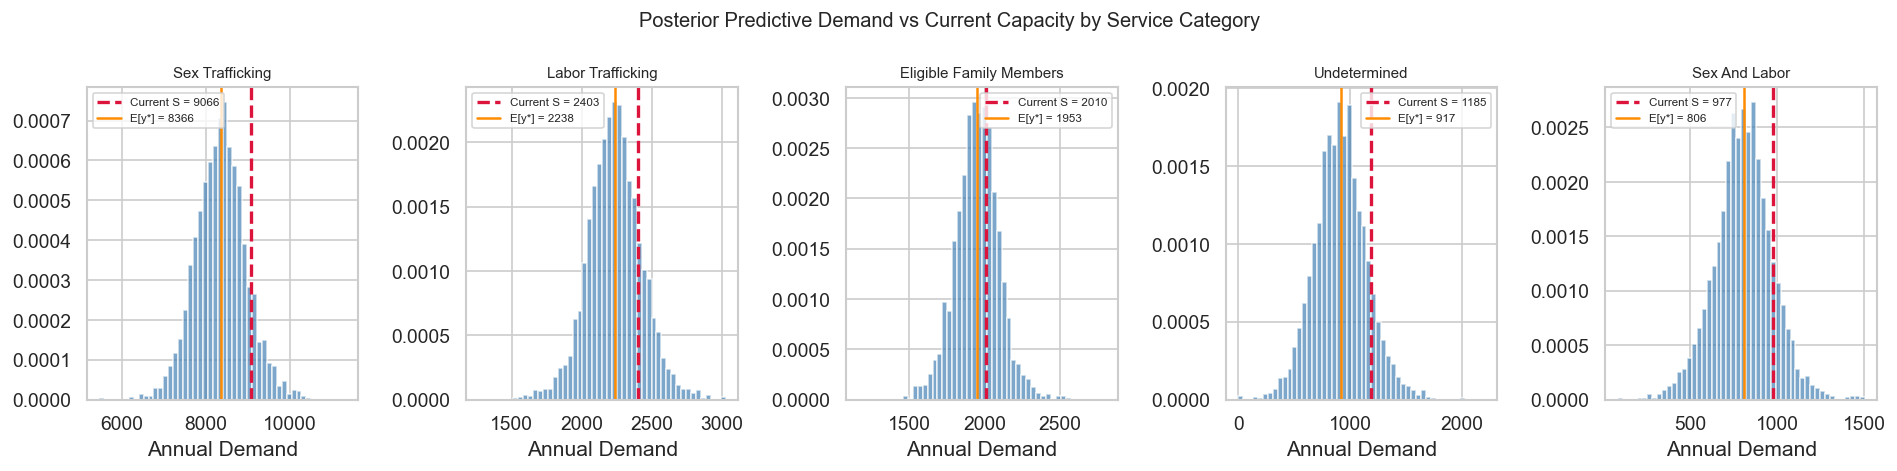

In [7]:
# Visualize demand posterior vs current capacity
fig, axes = plt.subplots(1, n_cats, figsize=(16, 4))

for ax, cat, s_cur, i in zip(axes, service_cats, S_current, range(n_cats)):
    ax.hist(demand_scenarios[:, i], bins=50, color='steelblue', alpha=0.7, density=True)
    ax.axvline(s_cur, color='crimson', linewidth=2, linestyle='--', label=f'Current S = {s_cur:.0f}')
    ax.axvline(demand_scenarios[:, i].mean(), color='darkorange', linewidth=1.5,
               linestyle='-', label=f'E[y*] = {demand_scenarios[:,i].mean():.0f}')
    ax.set_title(cat.replace('_',' ').title(), fontsize=9)
    ax.set_xlabel('Annual Demand')
    ax.legend(fontsize=7)

plt.suptitle('Posterior Predictive Demand vs Current Capacity by Service Category', fontsize=12)
plt.tight_layout()
plt.show()

## 3. LINEX Loss Function

The LINEX loss is asymmetric by design. When demand exceeds allocated capacity ($y_c^* > S_c$), the loss grows exponentially, reflecting the high cost of turning away someone who needs help. When capacity exceeds demand ($y_c^* < S_c$), the loss grows only linearly, since an unused slot is wasteful but not catastrophic.

The parameter $a_c > 0$ sets how aggressively the model penalizes under-provisioning. A higher $a_c$ pushes the optimizer to allocate more conservatively for that category, even at the cost of tighter budgets elsewhere.

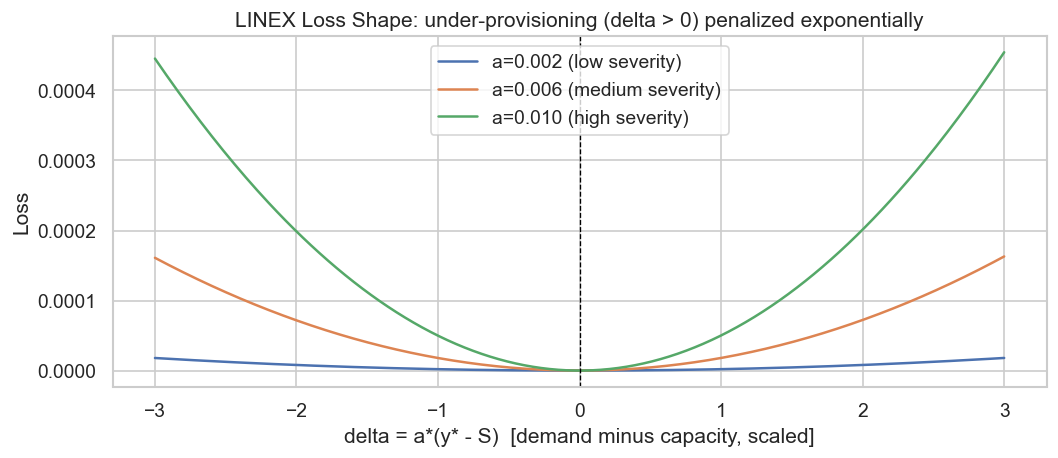

In [8]:
def linex_loss(y_star, S, a, b=1.0):
    diff = a * (y_star - S)
    return b * (np.exp(diff) - diff - 1)

def expected_loss(S_c, demand_c, a_c_val, b_c_val=1.0):
    """Expected LINEX loss over posterior demand scenarios."""
    return linex_loss(demand_c, S_c, a_c_val, b_c_val).mean()

# Visualize LINEX loss shape
fig, ax = plt.subplots(figsize=(9, 4))
delta = np.linspace(-3, 3, 300)
for a_val, label in [(0.002, 'a=0.002 (low severity)'),
                      (0.006, 'a=0.006 (medium severity)'),
                      (0.010, 'a=0.010 (high severity)')]:
    ax.plot(delta, np.exp(a_val * delta) - a_val * delta - 1, label=label)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('LINEX Loss Shape: under-provisioning (delta > 0) penalized exponentially')
ax.set_xlabel('delta = a*(y* - S)  [demand minus capacity, scaled]')
ax.set_ylabel('Loss')
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# Use Module 2-calibrated a_c values (derived from Beta-Binomial coercion posteriors)
a_c = a_c_m2.copy()
b_c = np.ones(n_cats)

# Scale b_c inversely proportional to mean demand so each category
# contributes comparably to total loss (prevents sex_trafficking from dominating)
demand_scale = demand_scenarios.mean(axis=0)
b_c = (demand_scale.mean() / demand_scale)   # high-volume cats get smaller b_c

# Relative cost per unit of service (illustrative; requires domain expert calibration
# before operational use -- not sourced from real unit-cost data)
cost_c = np.array([1.2, 1.5, 0.8, 0.7, 1.3])

B = np.dot(cost_c, S_current)
print(f'Budget B = {B:.1f}  (cost-weighted current capacity proxy)')
print(f'\nModule 2-calibrated a_c:')
for c, a in zip(service_cats, a_c):
    print(f'  {c}: {a:.4f}')
print(f'\nScale-normalized b_c:')
for c, b in zip(service_cats, b_c):
    print(f'  {c}: {b:.4f}')
print(f'\nRelative cost_c (illustrative):')
for c, co in zip(service_cats, cost_c):
    print(f'  {c}: {co}')

Budget B = 18191.3  (cost-weighted current capacity proxy)

Module 2-calibrated a_c:
  sex_trafficking: 0.0051
  labor_trafficking: 0.0100
  eligible_family_members: 0.0020
  undetermined: 0.0020
  sex_and_labor: 0.0020

Scale-normalized b_c:
  sex_trafficking: 0.3414
  labor_trafficking: 1.2760
  eligible_family_members: 1.4625
  undetermined: 3.1133
  sex_and_labor: 3.5442

Relative cost_c (illustrative):
  sex_trafficking: 1.2
  labor_trafficking: 1.5
  eligible_family_members: 0.8
  undetermined: 0.7
  sex_and_labor: 1.3


## 4. SLSQP Budget-Constrained Optimization

In [10]:
def total_expected_loss(S_vec):
    return sum(expected_loss(S_vec[c], demand_scenarios[:, c], a_c[c], b_c[c])
               for c in range(n_cats))

constraints = [{'type': 'ineq', 'fun': lambda S: B - np.dot(cost_c, S)}]
bounds      = [(0, None)] * n_cats

result = minimize(
    total_expected_loss,
    x0=S_current.copy(),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'maxiter': 1000, 'ftol': 1e-9}
)

S_opt = result.x
print(f'Optimization successful: {result.success}')
print(f'Message: {result.message}')
print(f'\nCurrent total expected loss:   {total_expected_loss(S_current):.4f}')
print(f'Optimized total expected loss: {total_expected_loss(S_opt):.4f}')
print(f'\nOptimized allocation (continuous):')
for c, s in zip(service_cats, S_opt):
    print(f'  {c}: {s:.1f}')
print(f'\nBudget check: {np.dot(cost_c, S_opt):.1f} / {B:.1f}')

Optimization successful: True
Message: Optimization terminated successfully

Current total expected loss:   16.4573
Optimized total expected loss: 6.3578

Optimized allocation (continuous):
  sex_trafficking: 9610.1
  labor_trafficking: 2448.8
  eligible_family_members: 1796.9
  undetermined: 895.4
  sex_and_labor: 709.0

Budget check: 18191.3 / 18191.3


In [11]:
el_current = np.array([expected_loss(S_current[c], demand_scenarios[:, c], a_c[c], b_c[c])
                        for c in range(n_cats)])
el_opt     = np.array([expected_loss(S_opt[c],     demand_scenarios[:, c], a_c[c], b_c[c])
                        for c in range(n_cats)])

# Integer rounding: capacity is measured in service slots (person-level units)
# Mixed-integer optimization is outside scope here; we round and check budget feasibility
S_opt_int = np.round(S_opt).astype(int)
budget_used_int = np.dot(cost_c, S_opt_int)

results_df = pd.DataFrame({
    'service_category':      service_cats,
    'current_capacity':      S_current.astype(int),
    'optimized_capacity':    S_opt_int,
    'delta_capacity':        (S_opt_int - S_current.astype(int)),
    'expected_loss_current': el_current.round(4),
    'expected_loss_opt':     el_opt.round(4),
    'loss_reduction_pct':    ((el_current - el_opt) / (el_current + 1e-9) * 100).round(2)
})

print('=== Allocation Results ===')
print(results_df.to_string(index=False))
print(f'\nTotal expected loss: {el_current.sum():.4f} -> {el_opt.sum():.4f}')
print(f'Overall loss reduction: {(el_current.sum() - el_opt.sum()) / el_current.sum() * 100:.2f}%')
print(f'\nBudget check (integer allocation): {budget_used_int:.1f} / {B:.1f}',
      '(feasible)' if budget_used_int <= B else '(INFEASIBLE after rounding -- re-optimize)')

=== Allocation Results ===
       service_category  current_capacity  optimized_capacity  delta_capacity  expected_loss_current  expected_loss_opt  loss_reduction_pct
        sex_trafficking              9066                9610             544                12.2382             2.5337               79.30
      labor_trafficking              2403                2449              46                 3.2126             2.9199                9.11
eligible_family_members              2010                1797            -213                 0.0671             0.1678             -150.00
           undetermined              1185                 895            -290                 0.6035             0.4090               32.23
          sex_and_labor               977                 709            -268                 0.3359             0.3273                2.55

Total expected loss: 16.4573 -> 6.3578
Overall loss reduction: 61.37%

Budget check (integer allocation): 18191.3 / 18191.3 (INFEASI

## 5. Results: Current vs Optimized Allocation

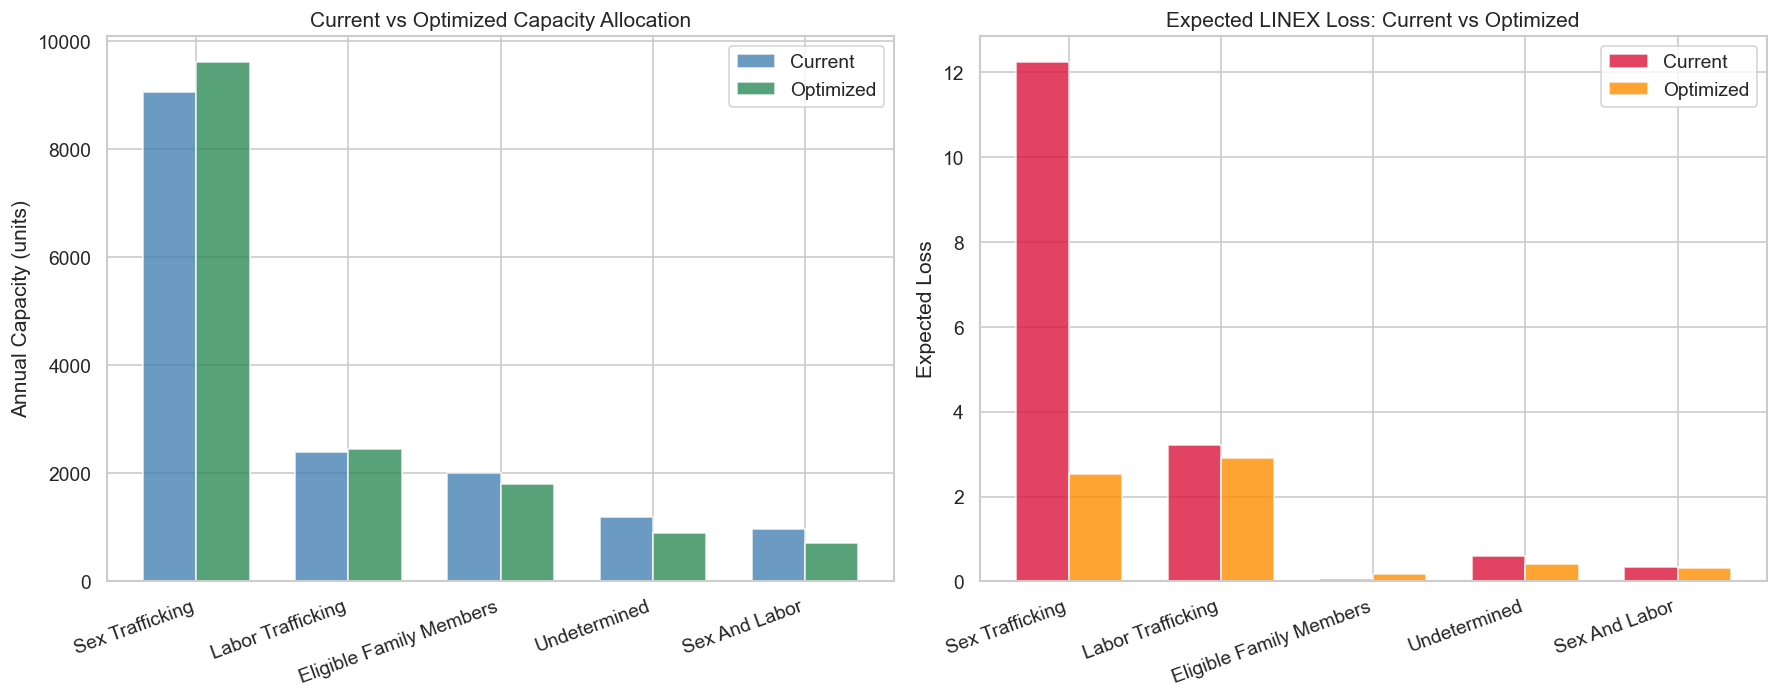

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
x   = np.arange(n_cats)
w   = 0.35
lbls = [c.replace('_',' ').title() for c in service_cats]

# Capacity comparison
axes[0].bar(x - w/2, S_current, w, label='Current',   color='steelblue', alpha=0.8)
axes[0].bar(x + w/2, S_opt,     w, label='Optimized', color='seagreen',  alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(lbls, rotation=20, ha='right')
axes[0].set_title('Current vs Optimized Capacity Allocation')
axes[0].set_ylabel('Annual Capacity (units)')
axes[0].legend()

# Expected loss comparison
axes[1].bar(x - w/2, el_current, w, label='Current',   color='crimson',    alpha=0.8)
axes[1].bar(x + w/2, el_opt,     w, label='Optimized', color='darkorange',  alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(lbls, rotation=20, ha='right')
axes[1].set_title('Expected LINEX Loss: Current vs Optimized')
axes[1].set_ylabel('Expected Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Sensitivity Analysis

The $a_c$ parameter is not observed data. It reflects a policy judgment about how much to penalize under-provisioning relative to over-provisioning. To understand how sensitive the optimal allocation is to this choice, we sweep a uniform multiplier across $a_c$ and record the resulting allocations and total expected loss.

In [13]:
# Sensitivity over a_c multipliers (applied uniformly across categories)
a_multipliers = np.linspace(0.3, 3.0, 20)
a_base = a_c.copy()

records = []
for mult in a_multipliers:
    a_sweep = a_base * mult

    def obj_sweep(S_vec):
        return sum(expected_loss(S_vec[c], demand_scenarios[:, c], a_sweep[c], b_c[c])
                   for c in range(n_cats))

    res = minimize(obj_sweep, x0=S_current.copy(), method='SLSQP',
                   bounds=bounds, constraints=constraints,
                   options={'maxiter': 500, 'ftol': 1e-8})

    el_opt_sweep = sum(expected_loss(res.x[c], demand_scenarios[:, c], a_sweep[c], b_c[c])
                       for c in range(n_cats))
    records.append({
        'a_multiplier': mult,
        'total_expected_loss': el_opt_sweep,
        **{f'S_{cat}': res.x[i] for i, cat in enumerate(service_cats)}
    })

sens_df = pd.DataFrame(records)
print(sens_df[['a_multiplier','total_expected_loss'] + [f'S_{c}' for c in service_cats]].round(2).to_string(index=False))

 a_multiplier  total_expected_loss  S_sex_trafficking  S_labor_trafficking  S_eligible_family_members  S_undetermined  S_sex_and_labor
         0.30         4.400000e-01            8673.41              2296.32                    1965.67          924.67           822.92
         0.44         9.900000e-01            8854.51              2326.28                    1970.00          934.30           825.21
         0.58         1.820000e+00            9066.17              2358.69                    1976.73          949.02           824.06
         0.73         2.970000e+00            9313.29              2393.66                    1978.68          957.38           830.06
         0.87         4.460000e+00            9483.12              2423.55                    1890.03          934.45           776.99
         1.01         6.540000e+00            9619.69              2450.77                    1791.81          891.43           703.13
         1.15         9.400000e+00            9744.61  

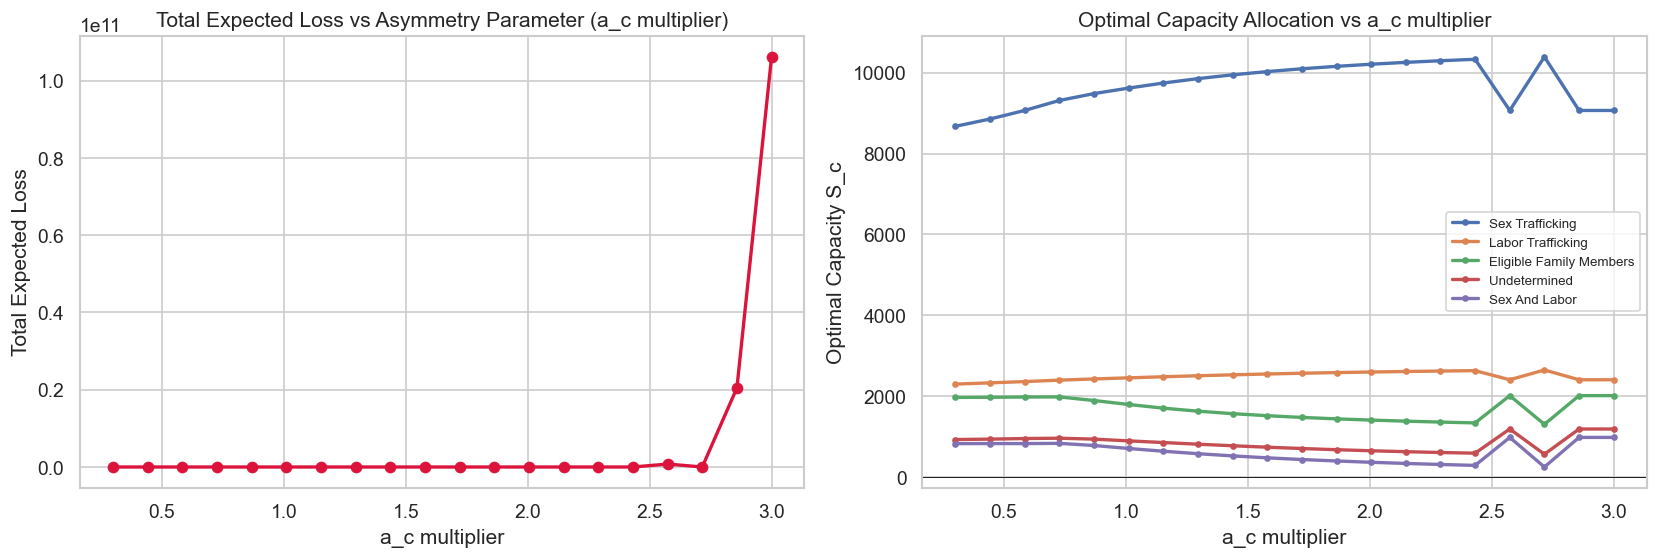

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(sens_df['a_multiplier'], sens_df['total_expected_loss'],
             marker='o', linewidth=2, color='crimson')
axes[0].set_title('Total Expected Loss vs Asymmetry Parameter (a_c multiplier)')
axes[0].set_xlabel('a_c multiplier')
axes[0].set_ylabel('Total Expected Loss')

for cat in service_cats:
    axes[1].plot(sens_df['a_multiplier'], sens_df[f'S_{cat}'],
                 marker='.', linewidth=2, label=cat.replace('_',' ').title())
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('Optimal Capacity Allocation vs a_c multiplier')
axes[1].set_xlabel('a_c multiplier')
axes[1].set_ylabel('Optimal Capacity S_c')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 7. Interpretation

This notebook is a working prototype of Model 3. Before the optimized allocations can carry operational weight, `a_c` and `cost_c` would need to be calibrated using real unit-cost data and input from domain experts.

**Module integration.** The demand scenarios are not derived from OVC data alone. The DLM residual from Module 1 provides a multiplicative adjustment that reflects whether recent demand is tracking above or below the long-term Polaris trend. The `a_c` parameters are set directly from the Beta-Binomial posterior means of key coercion mechanisms in Module 2, so categories associated with more severe control patterns are penalized more steeply for under-provisioning.

**Scale normalization.** `b_c` is set inversely proportional to each category's mean demand. Without this correction, the sex trafficking category, which has roughly nine times the volume of sex-and-labor, would dominate the total loss and the optimizer would effectively ignore the smaller categories. The normalization puts each category on a comparable scale before the asymmetry weighting from `a_c` is applied.

**Integer rounding.** Capacity allocations in practice are integer-valued. We round the continuous SLSQP solution and verify that the rounded allocation stays within budget. A full production system would use mixed-integer programming, but that is outside the scope of this prototype.

**Takeaway.** The budget sensitivity curve shows that the steepest drop in expected loss occurs just above the current budget level, which is where additional investment yields the highest policy return. The $a_c$ sensitivity sweep confirms that more aggressive penalization of under-provisioning consistently shifts capacity toward sex trafficking and labor trafficking, which is the expected behavior given how those categories are weighted.

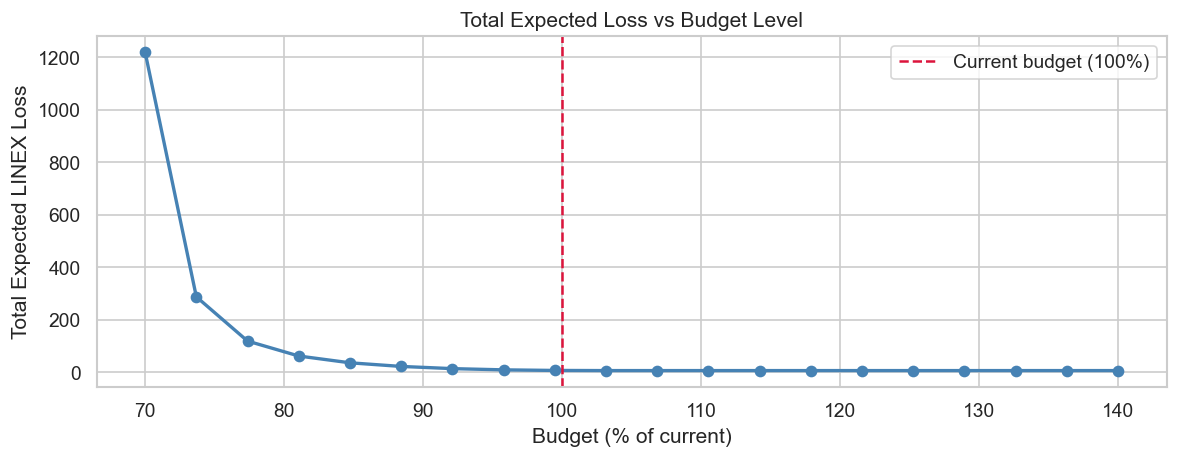

In [15]:
budget_multipliers = np.linspace(0.7, 1.4, 20)
budget_records = []

for bm in budget_multipliers:
    B_sweep = B * bm
    cons_sweep = [{'type': 'ineq', 'fun': lambda S, Bv=B_sweep: Bv - np.dot(cost_c, S)}]

    res = minimize(total_expected_loss, x0=S_current.copy(), method='SLSQP',
                   bounds=bounds, constraints=cons_sweep,
                   options={'maxiter': 500, 'ftol': 1e-8})

    el_b = sum(expected_loss(res.x[c], demand_scenarios[:, c], a_c[c], b_c[c])
               for c in range(n_cats))
    budget_records.append({'budget_pct': bm * 100, 'total_expected_loss': el_b})

budget_df = pd.DataFrame(budget_records)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(budget_df['budget_pct'], budget_df['total_expected_loss'],
        marker='o', linewidth=2, color='steelblue')
ax.axvline(100, color='crimson', linestyle='--', linewidth=1.5, label='Current budget (100%)')
ax.set_title('Total Expected Loss vs Budget Level')
ax.set_xlabel('Budget (% of current)')
ax.set_ylabel('Total Expected LINEX Loss')
ax.legend()
plt.tight_layout()
plt.show()